In [18]:
import pandas as pd
import numpy as np
from itertools import combinations
rng=np.random.default_rng(42)
df_sampling =pd.DataFrame(
    {
        'user_id':np.arange(1,101),
        'category':rng.choice(["A","B","C"], size=100, p=[0.5,0.3,0.2]),
        'score':rng.normal(loc=75,scale=10,size=100).round(2),
    }
)

In [19]:
print(f'The shape of the Dataframe: {df_sampling.shape}' )
print(f'The columns of the Dataframe: {df_sampling.columns}' )
df_sampling.head()

The shape of the Dataframe: (100, 3)
The columns of the Dataframe: Index(['user_id', 'category', 'score'], dtype='str')


,user_id,category,score
0,1,B,79.00
1,2,A,65.95
2,3,C,71.22
3,4,B,87.99
4,5,A,71.44


In [20]:
df_sampling['score'].describe()[['mean', 'std', 'min', 'max']]

mean     74.859800
std       9.843752
min      53.680000
max     104.140000
Name: score, dtype: float64

In [21]:
df_sampling['category'].value_counts().sort_index()

category
A    53
B    33
C    14
Name: count, dtype: int64

In [22]:
df_sampling.groupby('category')['score'].describe()[['mean', 'std', 'min', 'max']]

,mean,std,min,max
category,,,,
A,74.200000,8.973076,60.29,94.97
B,76.272424,10.014058,58.25,96.28
C,74.027857,12.705514,53.68,104.14


In [23]:
random_sample=df_sampling.sample(n=20,random_state=42)
random_sample.shape

(20, 3)

In [24]:

random_sample.groupby('category')['score'].describe()[['mean', 'std', 'min', 'max']]

,mean,std,min,max
category,,,,
A,71.211250,8.747513,61.23,83.40
B,75.071429,6.553916,64.64,83.38
C,67.838000,10.015841,53.68,77.68


In [25]:
random_sample['category'].value_counts().sort_index()

category
A    8
B    7
C    5
Name: count, dtype: int64

In [26]:
stratified_sample = (
    df_sampling
    .groupby("category", group_keys=False)
    .sample(frac=0.2, random_state=42)
    .reset_index(drop=True)
)

In [27]:
stratified_sample.head()

,user_id,category,score
0,39,A,78.14
1,84,A,77.19
2,93,A,92.24
3,29,A,89.63
4,86,A,86.06


In [28]:
stratified_sample.groupby('category')['score'].describe()[['mean','std','min','max']]

,mean,std,min,max
category,,,,
A,76.688182,10.510287,60.29,92.24
B,78.715714,10.081969,66.79,92.68
C,63.650000,5.447054,57.73,68.45


In [29]:
stratified_sample['category'].value_counts().sort_index()

category
A    11
B     7
C     3
Name: count, dtype: int64

In [30]:
df_sampling['category'].value_counts(normalize=True).sort_index()

category
A    0.53
B    0.33
C    0.14
Name: proportion, dtype: float64

In [31]:
stratified_sample = (
    df_sampling
    .groupby("category", group_keys=False)
    .sample(n=10, random_state=42)
    .reset_index(drop=True)
)

In [32]:
rng=np.random.default_rng(42)
df_random_split=df_sampling.assign(
    group=rng.choice(['control','treatment'],size=len(df_sampling))
)

In [33]:
df_random_split['group'].value_counts()

group
treatment    52
control      48
Name: count, dtype: int64

In [34]:
df_stratified_split = (
    df_sampling
    .assign(
        group=lambda x: (
            x.groupby("category")["user_id"]
            .transform(
                lambda g: rng.permutation(
                    ["control"] * (len(g)//2) + 
                    ["treatment"] * (len(g) - len(g)//2)
                )
            )
        )
    )
)

In [35]:
df_stratified_split[['group', 'category']].value_counts()

group      category
treatment  A           27
control    A           26
treatment  B           17
control    B           16
treatment  C            7
control    C            7
Name: count, dtype: int64

In [36]:
import numpy as np
import pandas as pd
import math
from statsmodels.stats.power import TTestIndPower
from statsmodels.stats.multitest import multipletests
from scipy.stats import ttest_ind
import scipy
import matplotlib.pyplot as plt

In [37]:
import sys
print(sys.executable)

c:\Users\Sargsyan\miniconda3\envs\aca\python.exe


In [38]:
import sys
!{sys.executable} -m pip install statsmodels scipy

In [39]:
from statsmodels.stats.power import TTestIndPower

In [40]:
N = TTestIndPower().solve_power(effect_size = 0.4, power = 0.8,
                            alpha = 0.05)

N

99.08032514676705

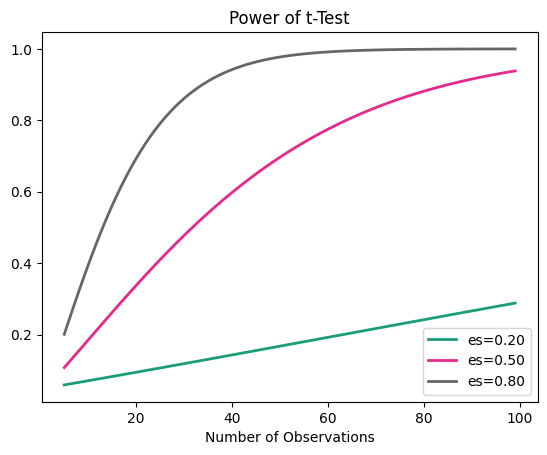

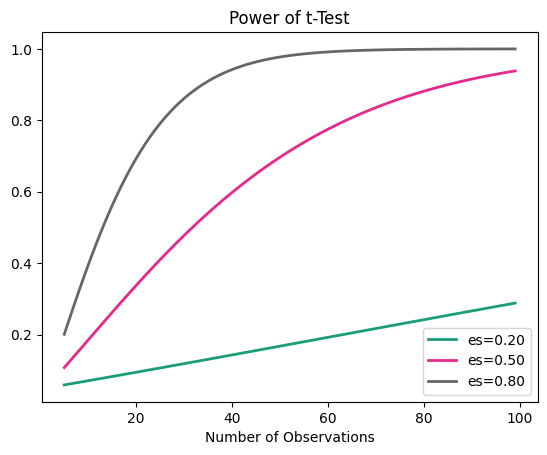

In [41]:
TTestIndPower().plot_power(dep_var='nobs',
                           nobs=np.array(range(5,100)),
                           effect_size=np.array([0.2,0.5,0.8]),
                           title='Power of t-Test')

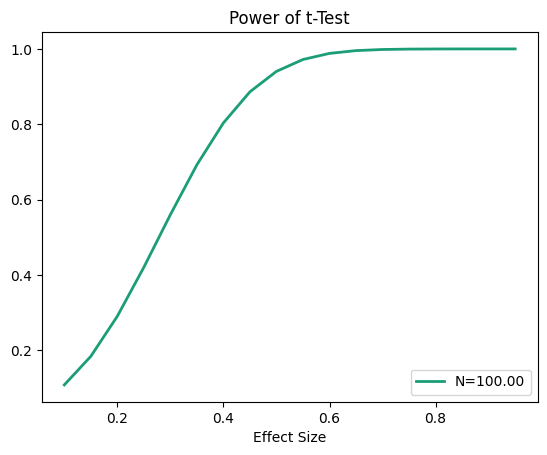

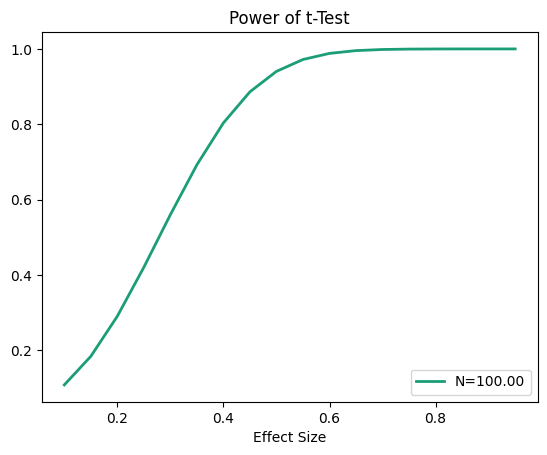

In [42]:
TTestIndPower().plot_power(dep_var='effect_size', nobs= [100],
                                 effect_size=np.arange(0.1, 1, 0.05),
                                 title='Power of t-Test')

In [43]:
TTestIndPower().solve_power(effect_size = 0.365, power = 0.8,
                            alpha = 0.05, alternative = 'larger')

93.4975695136995

In [44]:
expr = pd.read_csv('../data/ab_testing/experiment.csv')
expr.head()

,user_id,viewing_time,Group
0,4b5630ee914e848e8d07221556b0a2fb,38.354937,control
1,c01f179e4b57ab8bd9de309e6d576c48,49.534278,control
2,11946e7a3ed5e1776e81c0f0ecd383d0,35.468325,control
3,234a2a5581872457b9fe1187d1616b13,69.014875,control
4,dd4ad37ee474732a009111e3456e7ed7,51.547207,control


In [45]:
expr.groupby('Group')['viewing_time'].mean()

Group
control      48.386186
treatment    52.081302
Name: viewing_time, dtype: float64

In [46]:
ctrl = expr[expr['Group'] == 'control']['viewing_time']
treatment = expr[expr['Group'] == 'treatment']['viewing_time']

In [47]:
test_res = ttest_ind(treatment, ctrl)
tstat, pvalue=test_res

In [48]:
f"t-statistics: {tstat:.4f}"

't-statistics: 1.6002'

In [49]:
f"p-value: {pvalue:.4f}"

'p-value: 0.1128'

In [50]:
diff=treatment.mean() - ctrl.mean()
sd_pooled=math.sqrt((treatment.std()**2+ ctrl.std()**2)/2)

In [51]:
f"The detected Effect: {diff/sd_pooled:.4f}"

'The detected Effect: 0.3200'

In [52]:
def measures(data):
    desc = data.describe()
    x1 = desc.loc['mean', 'score1']
    x2 = desc.loc['mean', 'score2']
    s1 = desc.loc['std', 'score1']
    s2 = desc.loc['std', 'score2']
    return x1, x2, s1, s2

In [53]:
def ttest(x1,x2,s1,s2,n):
    t_value = (x1-x2)/math.sqrt(s1**2/n+s2**2/n)
    p_value = scipy.stats.t.sf(abs(t_value), df=n-1)*2
    return f't-value: {t_value:.4f}', f'p-value: {p_value:.4f}'

In [54]:
case1=pd.read_csv("../data/ab_testing/case1.csv")
case1.head()

,score1,score2
0,85,87
1,85,86
2,86,87
3,86,86
4,85,86


In [55]:
case1.describe().loc[['count','mean','std']]

,score1,score2
count,20.000000,20.000000
mean,85.550000,86.400000
std,0.510418,0.502625


In [56]:
# t-test for case 1
c1=measures(case1)
ttest(*c1,20)

('t-value: -5.3065', 'p-value: 0.0000')

In [57]:
case2=pd.read_csv("../data/ab_testing/case2.csv")
case2.head()

,score1,score2
0,88,95
1,89,88
2,91,93
3,94,87
4,87,89


In [58]:
case2.describe().loc[['count','mean','std']]

,score1,score2
count,20.000000,20.000000
mean,90.650000,90.750000
std,2.777257,2.788605


In [59]:
c2=measures(case2)
ttest(*c2,200)

('t-value: -0.3593', 'p-value: 0.7197')

In [60]:
c2=measures(case2)
ttest(*c2,200)

('t-value: -0.3593', 'p-value: 0.7197')

In [61]:
c2=measures(case2)
ttest(*c2,2000)

('t-value: -1.1363', 'p-value: 0.2560')

In [62]:
c2=measures(case2)
ttest(*c2,20000)

('t-value: -3.5933', 'p-value: 0.0003')

## Fast food chain 


In [63]:
import pandas as pd


In [64]:
df=pd.read_csv('../data/ab_testing/fast_food.csv')
df.head()

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


In [65]:
print(f"""
Rows           : {df.shape[0]}
Columns        : {df.shape[1]}

Features       :
{df.columns.tolist()}

Missing values : {df.isnull().sum().sum()}

Unique values  :
{df.nunique()}
""")


Rows           : 548
Columns        : 7

Features       :
['MarketID', 'MarketSize', 'LocationID', 'AgeOfStore', 'Promotion', 'week', 'SalesInThousands']

Missing values : 0

Unique values  :
MarketID             10
MarketSize            3
LocationID          137
AgeOfStore           25
Promotion             3
week                  4
SalesInThousands    517
dtype: int64



In [66]:
df.describe()

,MarketID,LocationID,AgeOfStore,Promotion,week,SalesInThousands
count,548.000000,548.000000,548.000000,548.000000,548.000000,548.000000
mean,5.715328,479.656934,8.503650,2.029197,2.500000,53.466204
std,2.877001,287.973679,6.638345,0.810729,1.119055,16.755216
min,1.000000,1.000000,1.000000,1.000000,1.000000,17.340000
25%,3.000000,216.000000,4.000000,1.000000,1.750000,42.545000
50%,6.000000,504.000000,7.000000,2.000000,2.500000,50.200000
75%,8.000000,708.000000,12.000000,3.000000,3.250000,60.477500
max,10.000000,920.000000,28.000000,3.000000,4.000000,99.650000


In [67]:
fig = px.box(
    df,
    x="Promotion",
    y="SalesInThousands",
    color="Promotion",
    title="Sales Distribution by Promotion"
)
fig.show()

NameError: name 'px' is not defined

In [ ]:
import plotly.express as px

In [ ]:
promo_avg = (
    df.groupby("Promotion")["SalesInThousands"]
    .mean()
    .reset_index()
)

fig = px.bar(
    promo_avg,
    x="Promotion",
    y="SalesInThousands",
    text="SalesInThousands",
    title="Average Sales by Promotion"
)
fig.show()

In [ ]:
weekly_sales = (
    df.groupby(["week", "Promotion"])["SalesInThousands"]
    .mean()
    .reset_index()
)

fig = px.line(
    weekly_sales,
    x="week",
    y="SalesInThousands",
    color="Promotion",
    markers=True,
    title="Weekly Sales Trend by Promotion"
)
fig.show()

In [ ]:
fig = px.box(
    df,
    x="MarketSize",
    y="SalesInThousands",
    color="Promotion",
    title="Sales by Market Size and Promotion"
)
fig.show()

In [ ]:
fig = px.scatter(
    df,
    x="AgeOfStore",
    y="SalesInThousands",
    color="Promotion",
    trendline="ols",
    title="Sales vs Store Age"
)
fig.show()

In [68]:
# better: aggregate per store first
store_level = (
    df.groupby(["LocationID", "Promotion"])["SalesInThousands"]
    .mean()
    .reset_index()
)

In [ ]:
from scipy.stats import ttest_ind

In [ ]:
from statsmodels.stats.power import TTestIndPower

In [ ]:
from statsmodels.stats.multitest import multipletests

In [ ]:
import scipy

In [ ]:
import matplotlib.pyplot as plt

In [69]:
t,p = ttest_ind(
    store_level[store_level["Promotion"] == 1]["SalesInThousands"],
    store_level[store_level["Promotion"] == 2]["SalesInThousands"],
    equal_var=False
)

print(f"T-statistic: {t:.4f}, P-value: {p:.4f}")

T-statistic: 3.3321, P-value: 0.0013


In [71]:
t, p = ttest_ind(
    df.loc[df['Promotion'] == 1, 'SalesInThousands'].values, 
    df.loc[df['Promotion'] == 3, 'SalesInThousands'].values, 
    equal_var=False)

print("t-value = " +str(t))
print("p-value = " +str(p))

t-value = 1.5560224307758634
p-value = 0.12059147742229487
